<a href="https://colab.research.google.com/github/guruswamyCN/EV-Data-Analysis/blob/main/jupyter_note_book.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

County                  1
City                    1
Postal Code             1
Legislative District    1
Vehicle Location        2
Electric Utility        2
2020 Census Tract       2
dtype: int64
Missing and zero values handled successfully
Duplicate Rows: 0
Duplicates removed successfully
   VIN (1-10)                                     VIN_Anonymized
0  1N4AZ0CP6D  25e6a27ac0ce5328a0ccb723ba3f51c311f2904004ae04...
1  5YJ3E1EC8L  9bdcc96fd653d922b7197ec170319ed7e503614272f520...
2  5YJ3E1EBXJ  e98075d3f536ea2802dc5ee28f0572d2eca2d1140b3fc9...
3  ZFAFFAC45R  a3a08d57dc55f552030b419883e71583b1a65e08e3f05e...
4  5YJYGDEE3L  1c9d2d25cd197a4ce1ae18cfa52ba501595bc080e302b5...
              Vehicle Location   Longitude  Latitude
0  POINT (-122.22901 47.72201)  -122.22901  47.72201
1    POINT (-122.521 47.62759)    -122.521  47.62759
2  POINT (-122.30866 47.57874)  -122.30866  47.57874
3  POINT (-122.60735 46.94239)  -122.60735  46.94239
4  POINT (-122.19975 47.37483)  -122.19975  47.37483
To

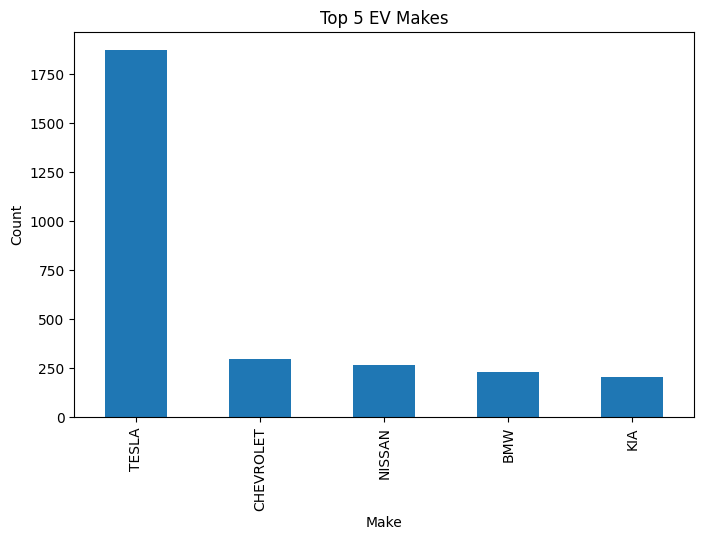

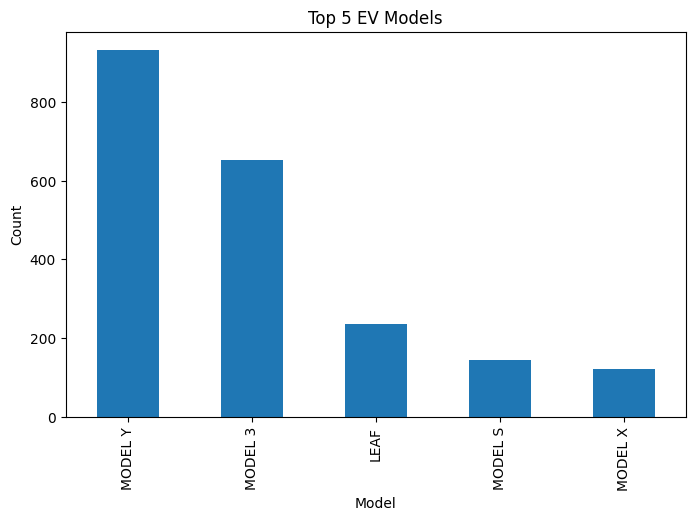

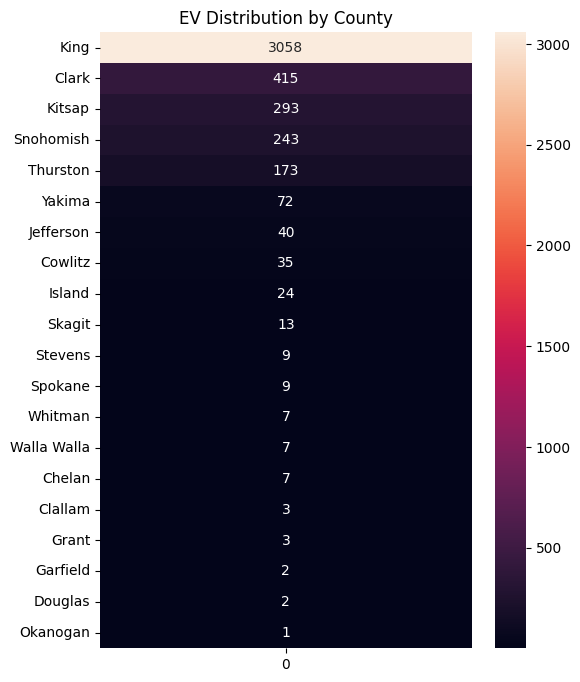

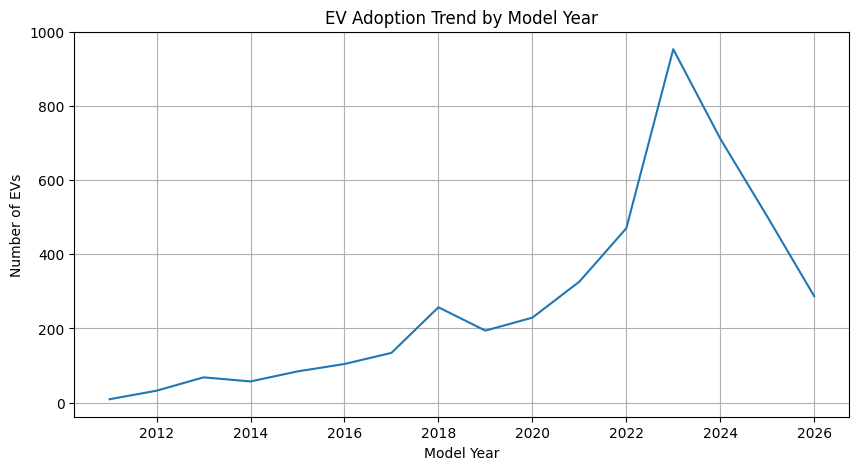

Base MSRP column not available


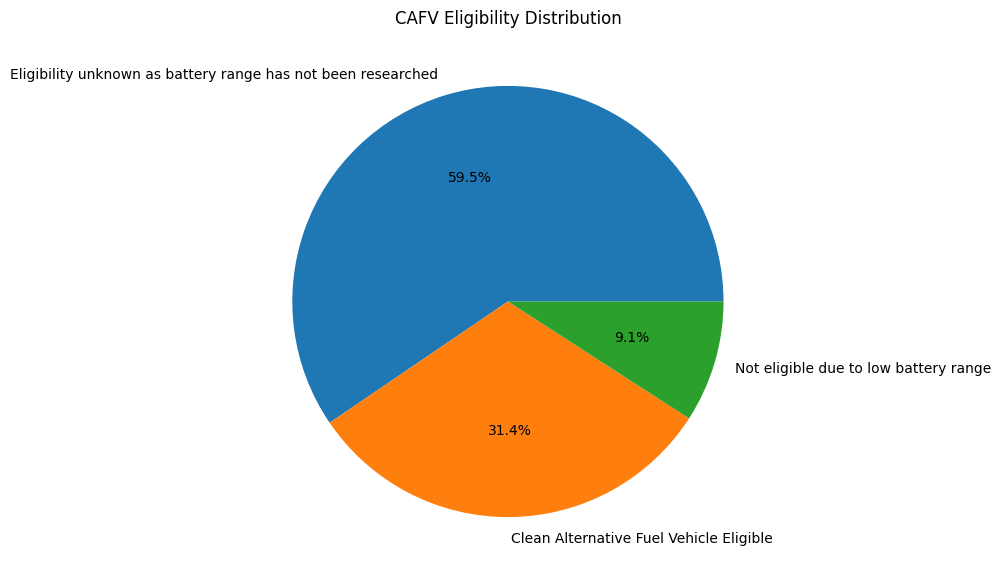

Map saved as EV_Registration_Map.html
Linear Regression Model Created Successfully
Features used for prediction:
['Model Year', 'Base MSRP', 'Make', 'Model']
   VIN (1-10)    County               City State  Postal Code  Model Year  \
0  1N4AZ0CP6D      King           Kirkland    WA      98034.0        2013   
1  5YJ3E1EC8L    Kitsap  Bainbridge Island    WA      98110.0        2020   
2  5YJ3E1EBXJ      King            Seattle    WA      98144.0        2018   
3  ZFAFFAC45R  Thurston               Yelm    WA      98597.0        2024   
4  5YJYGDEE3L      King               Kent    WA      98030.0        2020   

            Electric Vehicle Type  \
0  Battery Electric Vehicle (BEV)   
1  Battery Electric Vehicle (BEV)   
2  Battery Electric Vehicle (BEV)   
3  Battery Electric Vehicle (BEV)   
4  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible              75   
1           

In [2]:
# 1. How many missing values exist in the dataset, and in which columns?
import pandas as pd
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
missing_valves = df.isnull().sum()
print(missing_valves[missing_valves > 0])

# 2. How should missing or zero values in the Base MSRP and Electric Range columns be handled?
import numpy as np

# Electric Range Cleaning

df['Electric Range'] = df ['Electric Range'].replace(0, np.nan)
df['Electric Range'] = df['Electric Range'].fillna(
    df['Electric Range'].median()
)

# Base MSRP Cleaning

if 'Base MSRP' in df.columns:

    df['Base MSRP'] = df['Base MSRP'].replace(0, np.nan)

    df['Base MSRP'] = df['Base MSRP'].fillna(
        df['Base MSRP'].median()
    )

print("Missing and zero values handled successfully")

# 3. Are there duplicate records in the dataset? If so, how should they be managed?

duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

# Remove duplicates
df = df.drop_duplicates()

print("Duplicates removed successfully")

# 4. How can VINs be anonymized while maintaining uniqueness?

import hashlib

df['VIN_Anonymized'] = df['VIN (1-10)'].apply(
    lambda x: hashlib.sha256(str(x).encode()).hexdigest()
)

print(df[['VIN (1-10)', 'VIN_Anonymized']].head())



# 5. How can Vehicle Location (GPS coordinates) be cleaned or converted for better readability?

df[['Longitude', 'Latitude']] = df['Vehicle Location'].str.extract(
    r'POINT \(([-\d.]+) ([-\d.]+)\)'
)

print(df[['Vehicle Location', 'Longitude', 'Latitude']].head())

# 2. Data Exploration Questions

# 1. What are the top 5 most common EV makes and models in the dataset?

import pandas as pd

df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Top 5 Makes
top_makes = df['Make'].value_counts().head(5)

print("Top 5 EV Makes:\n")
print(top_makes)

# Top 5 Models
top_models = df['Model'].value_counts().head(5)

print("\nTop 5 EV Models:\n")
print(top_models)

# 2. What is the distribution of EVs by county?
# Which county has the most registrations?

county_distribution = df['County'].value_counts()

print(county_distribution)

print("\nCounty with Highest Registrations:")
print(county_distribution.idxmax())

# 3. How has EV adoption changed over different model years?

year_trend = df['Model Year'].value_counts().sort_index()

print(year_trend)

What is the average electric range of EVs in the dataset?

average_range = df['Electric Range'].mean()

print("Average Electric Range:", average_range)


# 5. What percentage of EVs are eligible for CAFV incentives?

cafv_percentage = (
    df['Clean Alternative Fuel Vehicle (CAFV) Eligibility']
    .value_counts(normalize=True) * 100
)

print(cafv_percentage)


# 6. How does the electric range vary across different makes and models?

range_by_make_model = df.groupby(
    ['Make', 'Model']
)['Electric Range'].mean().sort_values(ascending=False)

print(range_by_make_model)


# 7. What is the average Base MSRP for each EV model?

# Run only if Base MSRP column exists

if 'Base MSRP' in df.columns:

    avg_msrp = df.groupby('Model')['Base MSRP'].mean()

    print(avg_msrp)

else:
    print("Base MSRP column not available in dataset")


    # 8. Are there any regional trends in EV adoption (Urban vs Rural)?

regional_trends = df['County'].value_counts()

print(regional_trends)

# Optional: View top 10 counties
print("\nTop 10 Counties with Most EV Registrations:\n")
print(regional_trends.head(10))


# 1. Bar Chart - Top 5 EV Makes and Models by Count

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Top 5 Makes
top_makes = df['Make'].value_counts().head(5)

plt.figure(figsize=(8,5))
top_makes.plot(kind='bar')

plt.title("Top 5 EV Makes")
plt.xlabel("Make")
plt.ylabel("Count")

plt.show()


# Top 5 Models
top_models = df['Model'].value_counts().head(5)

plt.figure(figsize=(8,5))
top_models.plot(kind='bar')

plt.title("Top 5 EV Models")
plt.xlabel("Model")
plt.ylabel("Count")

plt.show()

# 2. Heatmap - EV Distribution by County

import seaborn as sns

county_data = df['County'].value_counts().head(20)

heatmap_data = county_data.values.reshape(-1,1)

plt.figure(figsize=(6,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g',
    yticklabels=county_data.index
)

plt.title("EV Distribution by County")

plt.show()


# 3. Line Graph - EV Adoption Trend by Model Year

year_trend = df['Model Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(year_trend.index, year_trend.values)

plt.title("EV Adoption Trend by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of EVs")

plt.grid(True)

plt.show()


# 4. Scatter Plot - Electric Range vs Base MSRP

# Run only if Base MSRP column exists

if 'Base MSRP' in df.columns:

    plt.figure(figsize=(8,5))

    plt.scatter(
        df['Electric Range'],
        df['Base MSRP']
    )

    plt.title("Electric Range vs Base MSRP")
    plt.xlabel("Electric Range")
    plt.ylabel("Base MSRP")

    plt.show()

else:
    print("Base MSRP column not available")


    # 5. Pie Chart - CAFV Eligible vs Non-Eligible EVs

cafv_counts = df[
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    cafv_counts,
    labels=cafv_counts.index,
    autopct='%1.1f%%'
)

plt.title("CAFV Eligibility Distribution")

plt.show()



# 6. Geospatial Map - EV Registrations by Vehicle Location

# Install if needed:
# pip install folium

import folium

# Extract Latitude and Longitude
df[['Longitude', 'Latitude']] = df['Vehicle Location'].str.extract(
    r'POINT \(([-\d.]+) ([-\d.]+)\)'
)

# Convert to numeric
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# Remove missing coordinates
map_data = df.dropna(subset=['Latitude', 'Longitude'])

# Create Map
ev_map = folium.Map(
    location=[
        map_data['Latitude'].mean(),
        map_data['Longitude'].mean()
    ],
    zoom_start=7
)

# Add sample markers
for _, row in map_data.head(500).iterrows():

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3
    ).add_to(ev_map)

# Save Map
ev_map.save("EV_Registration_Map.html")

print("Map saved as EV_Registration_Map.html")

# 4 Linear Regression Model Questions

# 1. How can we use Linear Regression to predict the Electric Range of a vehicle?

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Select Features
X = df[['Model Year']]

# Target Variable
y = df['Electric Range']

# Remove missing values
data = pd.concat([X, y], axis=1).dropna()

X = data[['Model Year']]
y = data['Electric Range']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Created Successfully")


# 2. What independent variables (features) can be used
# to predict Electric Range?

features = [
    'Model Year',
    'Base MSRP',
    'Make',
    'Model'
]

print("Features used for prediction:")
print(features)


# 3. How do we handle categorical variables
# like Make and Model in regression analysis?

# Convert categorical columns into numerical columns
# using One-Hot Encoding

encoded_df = pd.get_dummies(
    df,
    columns=['Make', 'Model'],
    drop_first=True
)

print(encoded_df.head())


# 4. What is the R² score of the model,
# and what does it indicate about prediction accuracy?

from sklearn.metrics import r2_score

# Predict
y_pred = model.predict(X_test)

# R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

# Interpretation
if r2 > 0.8:
    print("Excellent Prediction Accuracy")

elif r2 > 0.5:
    print("Moderate Prediction Accuracy")

else:
    print("Low Prediction Accuracy")


    # 5. How does the Base MSRP influence
# the Electric Range according to the regression model?

# Run only if Base MSRP column exists

if 'Base MSRP' in df.columns:

    from sklearn.linear_model import LinearRegression

    temp_df = df[['Base MSRP', 'Electric Range']].dropna()

    X = temp_df[['Base MSRP']]
    y = temp_df['Electric Range']

    model = LinearRegression()
    model.fit(X, y)

    coefficient = model.coef_[0]

    print("Coefficient:", coefficient)

    if coefficient > 0:
        print("Higher MSRP increases Electric Range")

    else:
        print("Higher MSRP decreases Electric Range")

else:
    print("Base MSRP column not available")



    # 6. What steps are needed to improve
# the accuracy of the Linear Regression model?

steps = [
    "Handle missing values properly",
    "Remove outliers",
    "Use more relevant features",
    "Apply feature engineering",
    "Encode categorical variables correctly",
    "Normalize numerical data",
    "Use larger datasets",
    "Try advanced models like Random Forest"
]

for step in steps:
    print(step)


    # 7. Can we use this model to predict
# the range of new EV models?

# Example Prediction

new_data = pd.DataFrame({
    'Model Year': [2025]
})

predicted_range = model.predict(new_data)

print("Predicted Electric Range:", predicted_range[0])


# Save cleaned dataset as CSV file

df.to_csv("Cleaned_Electric_Vehicle_Data.csv", index=False)

print("File saved successfully")

